In [30]:
!pip install matplotlib seaborn


  Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (5.1 kB)
  Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
Using cached matplotlib-3.10.8-cp313-cp313-macosx_11_0_arm64.whl (8.1 MB)
Using cached contourpy-1.3.3-cp313-cp313-macosx_11_0_arm64.whl (274 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp313-cp313-macosx_10_13_universal2.whl (2.9 MB)
Using cached kiwisolver-1.5.0-cp313-cp313-macosx_11_0_arm64.whl (64 kB)
Using cached pillow-12.2.0-cp313-cp313-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2

In [1]:
import clickhouse_connect
import psycopg2
import pandas as pd
from scipy.stats import mannwhitneyu
import datetime

In [2]:
CH_HOST = '185.71.196.185'
CH_DB = 'metrics'

PG_HOST = '185.71.196.185'
PG_DB = 'perfx'
PG_USER = 'perfx_user'
PG_PASSWORD = 'perfx_pass'

THRESHOLD_DELTA = 0.15      
P_VALUE_THRESHOLD = 0.05  

In [12]:
def get_clickhouse_client():
    return clickhouse_connect.get_client(host=CH_HOST, database=CH_DB, username = "metrics_user", password = "metrics_pass")

def get_postgres_connection():
    return psycopg2.connect(host=PG_HOST, database=PG_DB, user=PG_USER, password=PG_PASSWORD)

def find_regression_candidates(ch_client):
    # (Same ClickHouse query as before to find the P95 deltas)
    # query = f"""
    #     SELECT 
    #         project_id, metric_id, screen_name, device_cohort,
    #         quantileIf(0.95)(value, ts >= now() - INTERVAL 7 DAY AND ts < now() - INTERVAL 1 DAY) AS baseline_p95,
    #         quantileIf(0.95)(value, ts >= now() - INTERVAL 1 DAY) AS current_p95
    #     FROM metric_records
    #     WHERE ts >= now() - INTERVAL 7 DAY
    #     GROUP BY project_id, metric_id, screen_name, device_cohort
    #     HAVING baseline_p95 > 0 AND (current_p95 - baseline_p95) / baseline_p95 > {THRESHOLD_DELTA}
    # """

    query = f"""
        SELECT 
            project_id, metric_id, screen_name, device_cohort,
            quantileIf(0.95)(value, ts >= now() - INTERVAL 60 MINUTE AND ts < now() - INTERVAL 10 MINUTE) AS baseline_p95,
            quantileIf(0.95)(value, ts >= now() - INTERVAL 10 MINUTE) AS current_p95
        FROM metric_records
        WHERE ts >= now() - INTERVAL 60 MINUTE
        GROUP BY project_id, metric_id, screen_name, device_cohort
        HAVING baseline_p95 > 0 AND (current_p95 - baseline_p95) / baseline_p95 > {THRESHOLD_DELTA}
    """
    return ch_client.query_df(query)
def fetch_raw_data_for_test(ch_client, project_id, metric_id, screen_name, device_cohort):
    # (Same ClickHouse query as before to fetch the raw data arrays)
    query = f"""
        SELECT value, if(ts >= now() - INTERVAL 1 DAY, 'current', 'baseline') as window
        FROM metric_records
        WHERE project_id = '{project_id}' AND metric_id = '{metric_id}' 
          AND screen_name = '{screen_name}' AND device_cohort = '{device_cohort}'
          AND ts >= now() - INTERVAL 7 DAY
    """
    return ch_client.query_df(query)

def save_regression_to_postgres(pg_conn, info):
    """Saves the confirmed regression into PostgreSQL."""
    cursor = pg_conn.cursor()
    insert_query = """
        INSERT INTO regressions 
        (project_id, metric_id, screen_name, device_cohort, baseline_p95, current_p95, degradation_percent, p_value)
        VALUES (%s, %s, %s, %s, %s, %s, %s, %s)
    """
    cursor.execute(insert_query, (
        info['project_id'], info['metric_id'], info['screen_name'], info['device_cohort'],
        info['baseline_p95'], info['current_p95'], info['degradation_percent'], info['p_value']
    ))
    pg_conn.commit()
    cursor.close()

def run_pipeline():
    print(f"[{datetime.datetime.now()}] Starting Analysis...")
    ch_client = get_clickhouse_client()
    pg_conn = get_postgres_connection()
    
    candidates_df = find_regression_candidates(ch_client)
    
    if candidates_df.empty:
        print(f"[{datetime.datetime.now()}] No regression candidates found.")
        return

    print(f"[{datetime.datetime.now()}] Found {len(candidates_df)} regression candidates. Validating with statistical tests...")
    for _, row in candidates_df.iterrows():
        # Fetch data
        raw_df = fetch_raw_data_for_test(ch_client, row['project_id'], row['metric_id'], row['screen_name'], row['device_cohort'])
        
        baseline_values = raw_df[raw_df['window'] == 'baseline']['value']
        current_values = raw_df[raw_df['window'] == 'current']['value']
        
        # if len(baseline_values) < 5 or len(current_values) < 5:
        #     print(f"Not enough data for Project {row['project_id']} - Screen {row['screen_name']} - Device Cohort {row['device_cohort']}. Skipping statistical test.")
        #     continue

        plot_regression_analysis(
            raw_df=raw_df,
            metric_id=row["metric_id"],
            screen_name=row["screen_name"],
            cohort=row["device_cohort"],
            baseline_p95=row["baseline_p95"],
            current_p95=row["current_p95"],
            p_value=row["p_value"],
            delta=delta
        )

        # Validate with scipy
        stat, p_value = mannwhitneyu(current_values, baseline_values, alternative='greater')
        
        if p_value < P_VALUE_THRESHOLD:
            print(f"Confirmed regression for Project {row['project_id']} - Screen {row['screen_name']} - Device Cohort {row['device_cohort']} with p-value {p_value:.4f}")
            delta = (row['current_p95'] - row['baseline_p95']) / row['baseline_p95']
            info = {
                'project_id': row['project_id'],
                'metric_id': row['metric_id'],
                'screen_name': row['screen_name'],
                'device_cohort': row['device_cohort'],
                'baseline_p95': row['baseline_p95'],
                'current_p95': row['current_p95'],
                'degradation_percent': delta,
                'p_value': p_value
            }
            
            # Write to Postgres!
            save_regression_to_postgres(pg_conn, info)
            print(f"Saved regression to Postgres for Project {row['project_id']} - Screen {row['screen_name']}")
        else:
            print(f"Candidate regression NOT confirmed for Project {row['project_id']} - Screen {row['screen_name']} - Device Cohort {row['device_cohort']} with p-value {p_value:.4f}")

    pg_conn.close()

import matplotlib.pyplot as plt
import seaborn as sns

def plot_regression_analysis(raw_df, metric_id, screen_name, cohort, baseline_p95, current_p95, p_value, delta):
    # Set the style for a clean, academic look
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(10, 6))
    
    # 1. Draw the distributions (Histogram + KDE density curve)
    sns.histplot(
        data=raw_df, 
        x='value', 
        hue='window', 
        kde=True, 
        stat='density', 
        common_norm=False, 
        palette={'baseline': '#3498db', 'current': '#e74c3c'}, 
        alpha=0.5,
        bins=20
    )
    
    # 2. Draw vertical dashed lines for the P95 values
    plt.axvline(baseline_p95, color='#2980b9', linestyle='--', linewidth=2, 
                label=f'Baseline P95 ({baseline_p95:.1f})')
    plt.axvline(current_p95, color='#c0392b', linestyle='--', linewidth=2, 
                label=f'Current P95 ({current_p95:.1f})')
    
    # 3. Add Title and Labels with the math results
    degradation_pct = delta * 100
    title = (f"Performance Shift: {screen_name} | {metric_id} | {cohort}\n"
             f"Degradation: {degradation_pct:.1f}% | p-value: {p_value:.4f}")
    
    # If p-value < 0.05, make the title red to indicate a confirmed anomaly!
    title_color = 'red' if p_value < 0.05 else 'black'
    
    plt.title(title, fontsize=14, fontweight='bold', color=title_color)
    plt.xlabel("Metric Value (e.g., ms or MB)", fontsize=12)
    plt.ylabel("Density (Frequency)", fontsize=12)
    plt.legend()
    
    plt.tight_layout()
    plt.show()

def plot_debug_info(raw_df, metric_id, screen_name, cohort, baseline_p95, current_p95, p_value, delta):
    """Draws the distribution to debug the math before confirming."""
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(8, 5))
    
    # Draw distributions
    sns.histplot(
        data=raw_df, x='value', hue='window', kde=True, stat='density', 
        common_norm=False, palette={'baseline': '#3498db', 'current': '#e74c3c'}, 
        alpha=0.5, bins=15
    )
    
    # Draw P95 lines
    plt.axvline(baseline_p95, color='#2980b9', linestyle='--', linewidth=2, label=f'Baseline P95: {baseline_p95:.1f}')
    plt.axvline(current_p95, color='#c0392b', linestyle='--', linewidth=2, label=f'Current P95: {current_p95:.1f}')
    
    # Title with debug info
    status = "🚨 CONFIRMED" if p_value < P_VALUE_THRESHOLD else "❌ REJECTED (False Positive)"
    title_color = 'red' if p_value < P_VALUE_THRESHOLD else 'grey'
    
    plt.title(f"{screen_name} | {metric_id} | {cohort}\n"
              f"Degradation: {delta*100:.1f}% | p-value: {p_value:.4f} | {status}", 
              fontsize=12, fontweight='bold', color=title_color)
    
    plt.xlabel("Metric Value", fontsize=10)
    plt.ylabel("Density", fontsize=10)
    plt.legend()
    plt.tight_layout()
    plt.show()

In [23]:
BASELINE_START_MIN = 10   # Look back this far for the baseline start
CURRENT_START_MIN = 3     # The current window starts this many minutes ago
METRIC_ID = 'frameTime'
APP_ID = 'com.ndevelop.perfx'

Fetching frameTime data...
Found 730 Baseline points and 335 Current points.


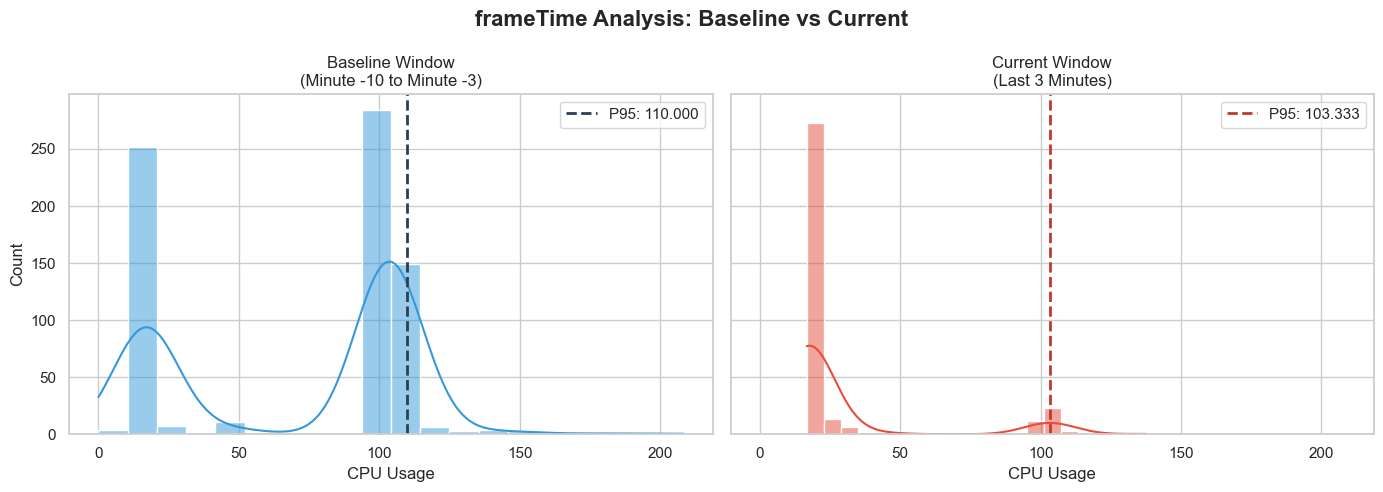

In [29]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# --- Easy-to-change Variables ---


# 1. Fetch the raw data from ClickHouse
query_raw_cpu = f"""
    SELECT 
        value, 
        if(ts >= now() - INTERVAL {CURRENT_START_MIN} MINUTE, 'Current', 'Baseline') as window
    FROM metric_records
    WHERE metric_id = '{METRIC_ID}' AND package_name = '{APP_ID}' AND device_cohort = 'Medium' 
      AND ts >= now() - INTERVAL {BASELINE_START_MIN} MINUTE
"""

print(f"Fetching {METRIC_ID} data...")
raw_df = client.query_df(query_raw_cpu)

if raw_df.empty:
    print(f"No {METRIC_ID} data found in the last {BASELINE_START_MIN} minutes.")
else:
    # Separate the data into two groups
    baseline_data = raw_df[raw_df['window'] == 'Baseline']['value']
    current_data = raw_df[raw_df['window'] == 'Current']['value']
    
    print(f"Found {len(baseline_data)} Baseline points and {len(current_data)} Current points.")

    # 2. Create Two Side-by-Side Plots
    sns.set_theme(style="whitegrid")
    fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
    fig.suptitle(f"{METRIC_ID} Analysis: Baseline vs Current", fontsize=16, fontweight='bold')

    # --- Plot 1: BASELINE ---
    if not baseline_data.empty:
        p95_base = baseline_data.quantile(0.95)
        sns.histplot(baseline_data, ax=axes[0], color='#3498db', kde=True, bins=20)
        axes[0].axvline(p95_base, color='#2c3e50', linestyle='--', linewidth=2, label=f'P95: {p95_base:.3f}')
        axes[0].set_title(f"Baseline Window\n(Minute -{BASELINE_START_MIN} to Minute -{CURRENT_START_MIN})")
        axes[0].set_xlabel("CPU Usage")
        axes[0].set_ylabel("Count")
        axes[0].legend()
    else:
        axes[0].set_title("Baseline Window\n(No Data)")

    # --- Plot 2: CURRENT ---
    if not current_data.empty:
        p95_curr = current_data.quantile(0.95)
        sns.histplot(current_data, ax=axes[1], color='#e74c3c', kde=True, bins=20)
        axes[1].axvline(p95_curr, color='#c0392b', linestyle='--', linewidth=2, label=f'P95: {p95_curr:.3f}')
        axes[1].set_title(f"Current Window\n(Last {CURRENT_START_MIN} Minutes)")
        axes[1].set_xlabel("CPU Usage")
        axes[1].legend()
    else:
        axes[1].set_title("Current Window\n(No Data)")

    plt.tight_layout()
    plt.show()

Fetching time-series data...


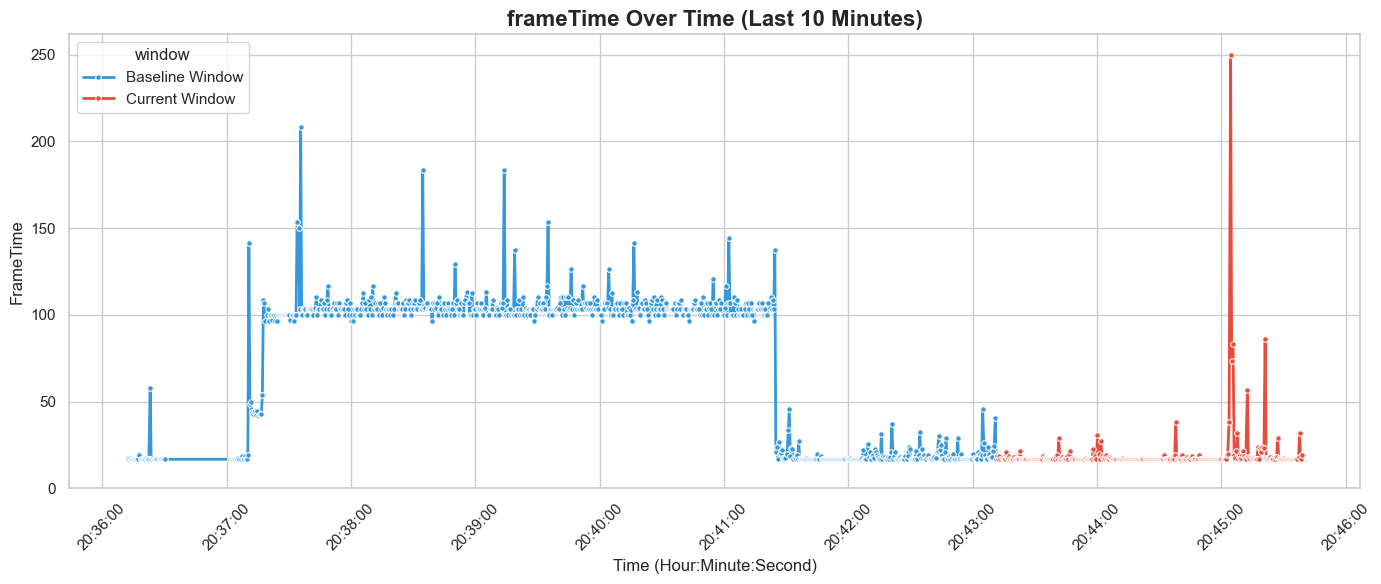

In [40]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import pandas as pd

# --- Variables ---

# 1. Fetch the raw data including the exact Timestamp (ts)
query_time_series = f"""
    SELECT 
        ts, 
        value, 
        if(ts >= now() - INTERVAL {CURRENT_START_MIN} MINUTE, 'Current Window', 'Baseline Window') as window
    FROM metric_records
     WHERE metric_id = '{METRIC_ID}' AND package_name = '{APP_ID}' AND device_cohort = 'Medium' 
      AND ts >= now() - INTERVAL {BASELINE_START_MIN} MINUTE
    ORDER BY ts ASC
"""

print("Fetching time-series data...")
ts_df = client.query_df(query_time_series)

if ts_df.empty:
    print("No data found!")
else:
    # 2. Draw the Time-Series Line Plot
    sns.set_theme(style="whitegrid")
    plt.figure(figsize=(14, 6))

    # Draw the line connecting all CPU values over time
    sns.lineplot(
        data=ts_df, 
        x='ts', 
        y='value', 
        hue='window',
        palette={'Baseline Window': '#3498db', 'Current Window': '#e74c3c'},
        linewidth=2,
        marker='o',      # Adds a dot for every single measurement
        markersize=4
    )

    # 3. Format the X-axis to show Minutes clearly
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))
    plt.xticks(rotation=45)

    # 4. Add labels and title
    plt.title(f"{METRIC_ID} Over Time (Last {BASELINE_START_MIN} Minutes)", fontsize=16, fontweight='bold')
    plt.xlabel("Time (Hour:Minute:Second)", fontsize=12)
    plt.ylabel("FrameTime", fontsize=12)
    
    # Set Y-axis to start at 0 so the scale makes sense
    plt.ylim(bottom=0)

    plt.tight_layout()
    plt.show()

In [31]:
print(f"[{datetime.datetime.now()}] Fetching candidates (Last 1m vs Previous 4m)...")
client = get_clickhouse_client()


query_frame_test = f"""
    SELECT
        quantileIf(0.95)(value, ts >= now() - INTERVAL {BASELINE_START_MIN} MINUTE AND ts < now() - INTERVAL {CURRENT_START_MIN} MINUTE) AS baseline_p95,

        quantileIf(0.95)(value, ts >= now() - INTERVAL {CURRENT_START_MIN} MINUTE) AS current_p95
        
    FROM metric_records 
    WHERE metric_id = 'frameTime'
      AND ts >= now() - INTERVAL {BASELINE_START_MIN} MINUTE -- Optimization: only scan the last {BASELINE_START_MIN} minutes of data
"""

frame_test_df = client.query_df(query_frame_test)
print("=== Frame Time Test (Last 5 Minutes) ===")
print(frame_test_df)

# 1. Find candidates using 10-minute testing windows
query_candidates = f"""
    SELECT 
        project_id, metric_id, screen_name, device_cohort,
        quantileIf(0.95)(value, ts >= now() - INTERVAL {BASELINE_START_MIN} MINUTE AND ts < now() - INTERVAL {CURRENT_START_MIN} MINUTE) AS baseline_p95,
        quantileIf(0.95)(value, ts >= now() - INTERVAL {CURRENT_START_MIN} MINUTE) AS current_p95
    FROM metric_records
    WHERE ts >= now() - INTERVAL {BASELINE_START_MIN} MINUTE
    GROUP BY project_id, metric_id, screen_name, device_cohort
    HAVING baseline_p95 > 0 AND (current_p95 - baseline_p95) / baseline_p95 > {THRESHOLD_DELTA}
"""
candidates_df = client.query_df(query_candidates)

if candidates_df.empty:
    print("No regression candidates found in the last 10 minutes.")
else:
    print(f"Found {len(candidates_df)} candidates. Fetching raw data for debug plotting...\n")
    print(candidates_df)

    for _, row in candidates_df.iterrows():
        # 2. Fetch raw data for this specific candidate
        if(row["metric_id"] != "frameTime"): continue
        query_raw = f"""
            SELECT value, if(ts >= now() - INTERVAL {CURRENT_START_MIN} MINUTE, 'current', 'baseline') as window
            FROM metric_records
            WHERE project_id = '{row['project_id']}' AND metric_id = '{row['metric_id']}' 
              AND screen_name = '{row['screen_name']}' AND device_cohort = '{row['device_cohort']}'
              AND ts >= now() - INTERVAL {BASELINE_START_MIN} MINUTE
        """
        raw_df = client.query_df(query_raw)
        
        baseline_values = raw_df[raw_df['window'] == 'baseline']['value']
        current_values = raw_df[raw_df['window'] == 'current']['value']
        
        if len(baseline_values) < 5 or len(current_values) < 5:
            print(f"Skipping {row['screen_name']} - Not enough data points (Baseline: {len(baseline_values)}, Current: {len(current_values)})")
            continue

        # 3. Calculate p-value
        stat, p_value = mannwhitneyu(current_values, baseline_values, alternative='greater')
        delta = (row['current_p95'] - row['baseline_p95']) / row['baseline_p95']
        
        # 4. PLOT DEBUG INFO IMMEDIATELY (Before confirming)
        plot_debug_info(
            raw_df=raw_df, 
            metric_id=row['metric_id'], 
            screen_name=row['screen_name'], 
            cohort=row['device_cohort'], 
            baseline_p95=row['baseline_p95'], 
            current_p95=row['current_p95'], 
            p_value=p_value, 
            delta=delta
        )
        
        # 5. Now confirm and save if it passes the statistical test
        if p_value < P_VALUE_THRESHOLD:
            print(f"✅ Regression formally confirmed for {row['screen_name']}! (Saving to Postgres...)")
            # save_regression_to_postgres(...)
        else:
            print(f"🚫 Regression rejected for {row['screen_name']} by Mann-Whitney U test (p >= 0.05).")
        print("-" * 50)

[2026-04-07 23:44:44.145505] Fetching candidates (Last 1m vs Previous 4m)...
=== Frame Time Test (Last 5 Minutes) ===
   baseline_p95  current_p95
0    109.999996    23.328876
Found 1 candidates. Fetching raw data for debug plotting...

                             project_id metric_id                screen_name  \
0  a0f75220-7593-45fe-ac11-381327b69f18  cpuUsage  compose/ui_responsiveness   

  device_cohort  baseline_p95  current_p95  
0        Medium     64.082592    87.290604  


In [42]:
run_pipeline()

[2026-04-07 20:59:46.491716] Starting Analysis...
[2026-04-07 20:59:46.744925] Found 1 regression candidates. Validating with statistical tests...


KeyError: 'p_value'

In [29]:
baseline = df[df["app_version"] == BASELINE_VERSION]["value"].astype(float).to_numpy()
current = df[df["app_version"] == CURRENT_VERSION]["value"].astype(float).to_numpy()

len(baseline), len(current)

(3915, 3915)

In [30]:
MIN_SAMPLES = 50

if len(baseline) < MIN_SAMPLES or len(current) < MIN_SAMPLES:
    print("Not enough samples")
else:
    print("Enough samples")

Enough samples


In [31]:
def summarize(x):
    return {
        "count": len(x),
        "mean": np.mean(x),
        "p50": np.percentile(x, 50),
        "p95": np.percentile(x, 95),
        "p99": np.percentile(x, 99),
    }

baseline_stats = summarize(baseline)
current_stats = summarize(current)

baseline_stats, current_stats

({'count': 3915,
  'mean': np.float64(21.590581817894304),
  'p50': np.float64(16.666666000000006),
  'p95': np.float64(22.727271818181826),
  'p99': np.float64(52.68749757250037)},
 {'count': 3915,
  'mean': np.float64(21.590581817894304),
  'p50': np.float64(16.666666000000006),
  'p95': np.float64(22.727271818181826),
  'p99': np.float64(52.68749757250037)})

In [32]:
delta_p50 = (current_stats["p50"] - baseline_stats["p50"]) / baseline_stats["p50"]
delta_p95 = (current_stats["p95"] - baseline_stats["p95"]) / baseline_stats["p95"]

print("delta_p50 =", delta_p50)
print("delta_p95 =", delta_p95)

delta_p50 = 0.0
delta_p95 = 0.0


In [33]:
stat, p_value = mannwhitneyu(current, baseline, alternative="greater")
print("p_value =", p_value)

p_value = 0.5000022153621949


In [36]:
P95_THRESHOLD = 0.20   # 20%
P50_THRESHOLD = 0.10   # 10%
P_VALUE_THRESHOLD = 0.05

is_regression = (
    p_value < P_VALUE_THRESHOLD and
    (delta_p95 > P95_THRESHOLD or delta_p50 > P50_THRESHOLD)
)

print("Regression detected:", is_regression)

Regression detected: False
